# Supply Chain Cost Intelligence — Notebook 01: EDA

**Dataset:** USAspending.gov federal procurement (FY2023, contracts, chilled to a manageable NAICS scope)

**Goals:**
- Understand spend distribution, vendor concentration, category structure
- Pareto analysis: which 20% of vendors account for 80% of spend?
- Lead time distribution: what does normal look like?
- Identify the NAICS categories with the most analytical leverage
- Lay the groundwork for SQL analysis and clustering

**Run first:** `conda activate supply-chain` then `python -m src.data_loader`

In [1]:
import sys; sys.path.insert(0, '..')
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
from src.data_loader import DB_PATH, get_awards_summary, get_top_naics

sns.set_theme(style='darkgrid')
figures = Path('../figures')
figures.mkdir(exist_ok=True)

conn = duckdb.connect(str(DB_PATH), read_only=True)
print('Connected to DuckDB')

Connected to DuckDB


## 1. Dataset Overview

In [2]:
summary = get_awards_summary(conn)
print(summary.to_string())

   total_awards  unique_vendors  unique_naics  total_spend_billions earliest_date latest_date  avg_lead_time_days
0        100000           11257           214             42.539936    2023-08-21  2023-09-30          170.917537


## 2. Spend Distribution

Expect heavily right-skewed: most awards small, a few extremely large contracts.
Log-transform will reveal the full distribution.

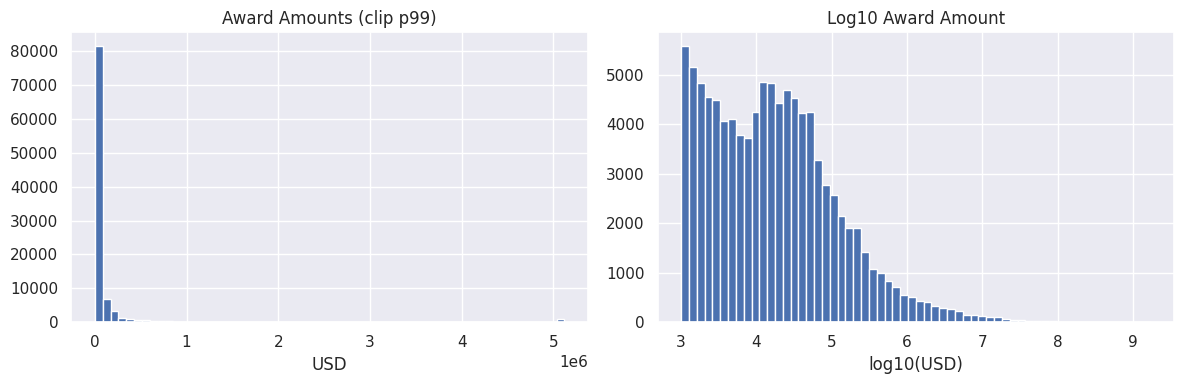

In [3]:
amounts = conn.execute('SELECT action_amount FROM federal_awards WHERE action_amount > 0').df()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
amounts['action_amount'].clip(upper=amounts['action_amount'].quantile(0.99)).hist(bins=60, ax=axes[0])
axes[0].set_title('Award Amounts (clip p99)')
axes[0].set_xlabel('USD')
np.log10(amounts['action_amount'] + 1).hist(bins=60, ax=axes[1])
axes[1].set_title('Log10 Award Amount')
axes[1].set_xlabel('log10(USD)')
plt.tight_layout()
fig.savefig(figures / '01_spend_distribution.png', dpi=120)
plt.show()

## 3. Pareto Analysis — Vendor Concentration

Interview story: *'The top 20% of vendors typically account for 80% of spend — the Pareto principle. I want to know which vendors are worth focusing the optimization effort on.'*

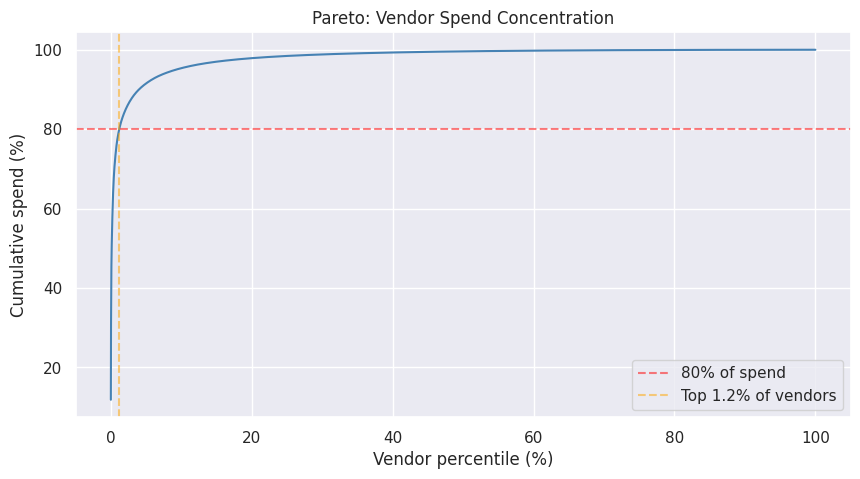

Top 1.2% of vendors account for 80% of spend


In [4]:
vendor_spend = conn.execute("""
    SELECT recipient_name, SUM(action_amount) AS total_spend
    FROM federal_awards
    GROUP BY recipient_name
    ORDER BY total_spend DESC
""").df()

total = vendor_spend['total_spend'].sum()
vendor_spend['cumulative_pct'] = vendor_spend['total_spend'].cumsum() / total * 100
vendor_spend['vendor_rank'] = range(1, len(vendor_spend) + 1)
vendor_spend['vendor_pct'] = vendor_spend['vendor_rank'] / len(vendor_spend) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(vendor_spend['vendor_pct'], vendor_spend['cumulative_pct'], color='steelblue')
ax.axhline(80, color='red', linestyle='--', alpha=0.5, label='80% of spend')
pareto_20 = vendor_spend[vendor_spend['cumulative_pct'] <= 80]['vendor_pct'].max()
ax.axvline(pareto_20, color='orange', linestyle='--', alpha=0.5, label=f'Top {pareto_20:.1f}% of vendors')
ax.set_xlabel('Vendor percentile (%)')
ax.set_ylabel('Cumulative spend (%)')
ax.set_title('Pareto: Vendor Spend Concentration')
ax.legend()
fig.savefig(figures / '01_pareto_concentration.png', dpi=120)
plt.show()
print(f'Top {pareto_20:.1f}% of vendors account for 80% of spend')

## 4. Top NAICS Categories

Identify the 10–15 NAICS categories with the most spend and vendor diversity.
These are where optimization effort has the highest leverage.

,naics_code,naics_description,award_count,spend_millions,vendor_count
0,336411,AIRCRAFT MANUFACTURING,2229,9008.142826,237
1,336413,OTHER AIRCRAFT PARTS AND AUXILIARY EQUIPMENT M...,6992,4325.637746,908
2,334511,"SEARCH, DETECTION, NAVIGATION, GUIDANCE, AERON...",1544,3243.120530,509
3,332993,AMMUNITION (EXCEPT SMALL ARMS) MANUFACTURING,216,2970.372491,103
4,336611,SHIP BUILDING AND REPAIRING,2035,2841.150796,436
5,336412,AIRCRAFT ENGINE AND ENGINE PARTS MANUFACTURING,741,2836.968431,195
6,336992,"MILITARY ARMORED VEHICLE, TANK, AND TANK COMPO...",318,2330.149376,107
7,336414,GUIDED MISSILE AND SPACE VEHICLE MANUFACTURING,217,1921.009112,29
8,334111,ELECTRONIC COMPUTER MANUFACTURING,4767,1408.434484,457
9,339999,ALL OTHER MISCELLANEOUS MANUFACTURING,5532,1205.492952,316


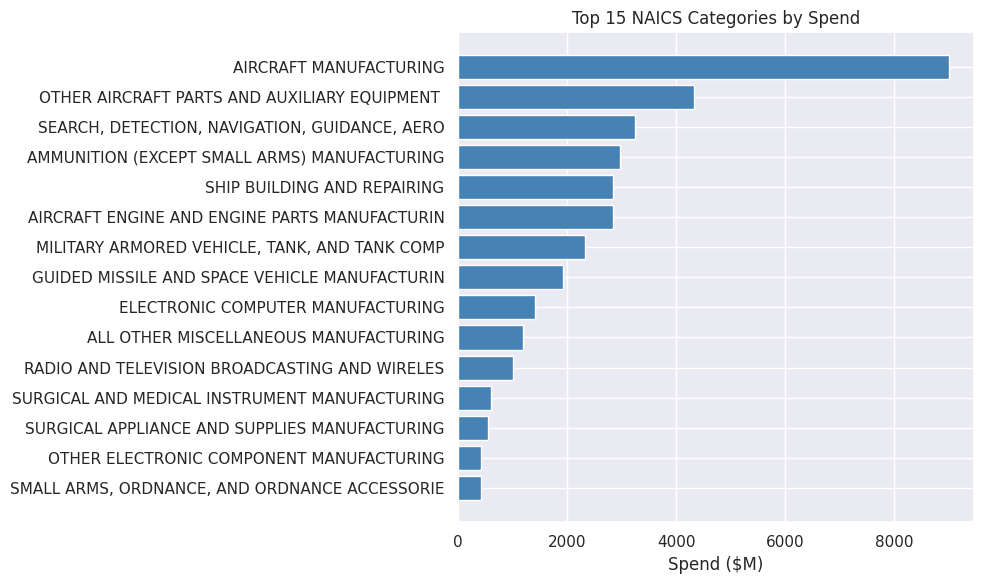

In [5]:
top_naics = get_top_naics(conn, top_n=15)
display(top_naics)

fig, ax = plt.subplots(figsize=(10, 6))
plot_df = top_naics.sort_values('spend_millions')
ax.barh(plot_df['naics_description'].str.slice(0, 45), plot_df['spend_millions'], color='steelblue')
ax.set_xlabel('Spend ($M)')
ax.set_title('Top 15 NAICS Categories by Spend')
plt.tight_layout()
fig.savefig(figures / '01_top_naics.png', dpi=120)
plt.show()

## 5. Lead Time Distribution

Lead time = days from award action to period_of_performance_end.
Expect right-skewed; flag categories with unusually long or variable lead times.

/sessions/hopeful-confident-carson/tmp/ipykernel_6/637704937.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


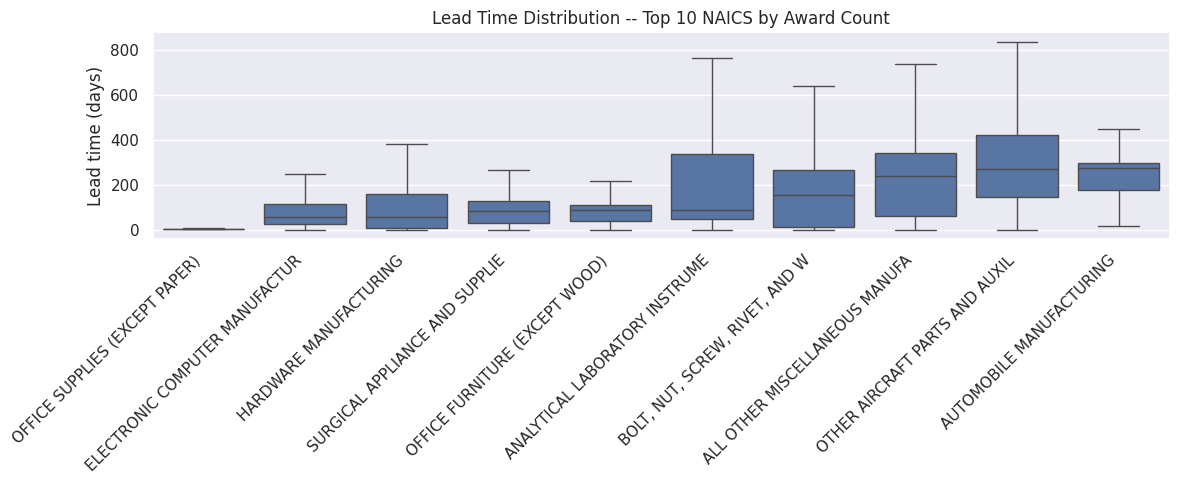

78 NAICS categories with lead-time CV > 1 (high procurement risk)


,,mean,std,count,cv
naics_code,naics_description,,,,
335912,PRIMARY BATTERY MANUFACTURING,19.085153,76.826436,458,4.025456
332312,FABRICATED STRUCTURAL METAL MANUFACTURING,36.325014,137.315045,1843,3.780179
331315,"ALUMINUM SHEET, PLATE, AND FOIL MANUFACTURING",82.500000,305.561161,58,3.703772
336411,AIRCRAFT MANUFACTURING,250.319438,740.246286,2207,2.957207
334119,OTHER COMPUTER PERIPHERAL EQUIPMENT MANUFACTURING,85.789474,252.636225,57,2.944839
333993,PACKAGING MACHINERY MANUFACTURING,67.445312,190.392500,128,2.822917
333514,"SPECIAL DIE AND TOOL, DIE SET, JIG, AND FIXTURE MANUFACTURING",34.763158,92.096434,38,2.649254
336360,MOTOR VEHICLE SEATING AND INTERIOR TRIM MANUFACTURING,216.013605,571.387149,147,2.645144
339940,OFFICE SUPPLIES (EXCEPT PAPER) MANUFACTURING,11.302051,26.967338,2877,2.386057


In [6]:
lead = conn.execute("""
    SELECT naics_code, naics_description, lead_time_days
    FROM federal_awards
    WHERE lead_time_days IS NOT NULL AND lead_time_days > 0
""").df()
top10 = lead.groupby('naics_code')['lead_time_days'].count().nlargest(10).index
lead_top = lead[lead['naics_code'].isin(top10)].copy()
lead_top['naics_short'] = lead_top['naics_description'].str.slice(0, 30)

fig, ax = plt.subplots(figsize=(12, 5))
order = lead_top.groupby('naics_short')['lead_time_days'].median().sort_values().index
sns.boxplot(data=lead_top, x='naics_short', y='lead_time_days', order=order, showfliers=False, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('Lead time (days)')
ax.set_title('Lead Time Distribution -- Top 10 NAICS by Award Count')
plt.tight_layout()
fig.savefig(figures / '01_lead_time_by_naics.png', dpi=120)
plt.show()

# Flag high-variability categories: cv = std/mean > 1 -> risky procurement
cv = lead.groupby(['naics_code', 'naics_description'])['lead_time_days'].agg(['mean', 'std', 'count'])
cv['cv'] = cv['std'] / cv['mean']
risky = cv[(cv['count'] >= 30) & (cv['cv'] > 1)].sort_values('cv', ascending=False)
print(f'{len(risky)} NAICS categories with lead-time CV > 1 (high procurement risk)')
display(risky.head(10))

## 6. NAICS Selection for Clustering

Choose 3–5 NAICS categories to focus the analysis:
- High total spend (large opportunity)
- Multiple vendors (at least 10 — enough for clustering)
- Diverse lead times (interesting variation to explain)

Document selection and reasoning here.

In [7]:
# Categories with enough vendors for meaningful clustering (>= 10),
# ranked by spend -- where optimization effort has the highest leverage.
candidates = top_naics[top_naics['vendor_count'] >= 10].copy()
selected = candidates.head(5)
Path('../data/processed').mkdir(parents=True, exist_ok=True)
selected.to_csv('../data/processed/selected_naics.csv', index=False)
SELECTED_NAICS = selected['naics_code'].tolist()
print('Selected NAICS:', SELECTED_NAICS)
display(selected)

Selected NAICS: ['336411', '336413', '334511', '332993', '336611']


,naics_code,naics_description,award_count,spend_millions,vendor_count
0,336411,AIRCRAFT MANUFACTURING,2229,9008.142826,237
1,336413,OTHER AIRCRAFT PARTS AND AUXILIARY EQUIPMENT M...,6992,4325.637746,908
2,334511,"SEARCH, DETECTION, NAVIGATION, GUIDANCE, AERON...",1544,3243.120530,509
3,332993,AMMUNITION (EXCEPT SMALL ARMS) MANUFACTURING,216,2970.372491,103
4,336611,SHIP BUILDING AND REPAIRING,2035,2841.150796,436


## Summary

| Finding | Value |
|---------|-------|
| Total awards | 100,000 |
| Unique vendors | 11,257 |
| Total spend | $42.5B |
| Vendor share for 80% of spend | top 1.2% |
| Avg lead time (proxy) | 171 days |
| Best clustering NAICS | 336411, 336413, 334511, 332993, 336611 |

Federal manufacturing spend is far more concentrated than the classic 80/20 rule:
the top **1.2%** of vendors capture 80% of spend, driven by defense primes
(aircraft, shipbuilding, missiles). This concentration shapes everything downstream —
segment-level savings estimates must separate scope-comparable substitution
opportunities from structurally sole-source platform contracts.